# RetainIQ — Churn Driver ID (Correlation, Chi-Square, SHAP Global Importance)

Identifies global churn drivers three ways: a numeric correlation-with-`Churn` ranking, a chi-square test of independence (with Cramér's V effect size) on CLAUDE.md §6's 9 "Services" categorical columns, and SHAP `TreeExplainer` global feature importance from a dedicated diagnostic XGBoost classifier. All logic lives in `src/explain/driver_analysis.py` — this notebook only calls into it and renders the results.

**Scope note:** this is *not* CLAUDE.md §14's Phase 2 (the production churn classifier) or Phase 3 (local/per-customer SHAP+LIME explanations). The diagnostic XGBoost model fit here is a throwaway fit that exists only to produce global SHAP importance — never persisted, never compared against other algorithms, and unrelated to whatever Phase 2 eventually builds. See `.claude/specs/06-churn-driver-id.md` for the full methodology and every verified number below.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.load_data import load_clean_data
from src.explain.driver_analysis import (
    LEAKAGE_AUC_THRESHOLD,
    chi_square_service_association,
    fit_driver_diagnostic_model,
    generate_driver_figures,
    numeric_correlation_with_churn,
    shap_global_importance,
)

pd.set_option("display.max_columns", None)
df = load_clean_data()
df.shape

(7043, 20)

Regenerate the driver-analysis charts before rendering any of them below, so the images this notebook displays are always current for whatever `df` was just loaded.

In [2]:
paths = generate_driver_figures(df)
print(f"Saved {len(paths)} figures to reports/figures/")

Saved 3 figures to reports/figures/


## 1. Numeric correlation with Churn

Pearson (point-biserial) correlation of each numeric column with `Churn`.

In [3]:
display(numeric_correlation_with_churn(df))

,column,correlation,abs_correlation
0,tenure,-0.3522,0.3522
1,TotalCharges,-0.1983,0.1983
2,MonthlyCharges,0.1934,0.1934


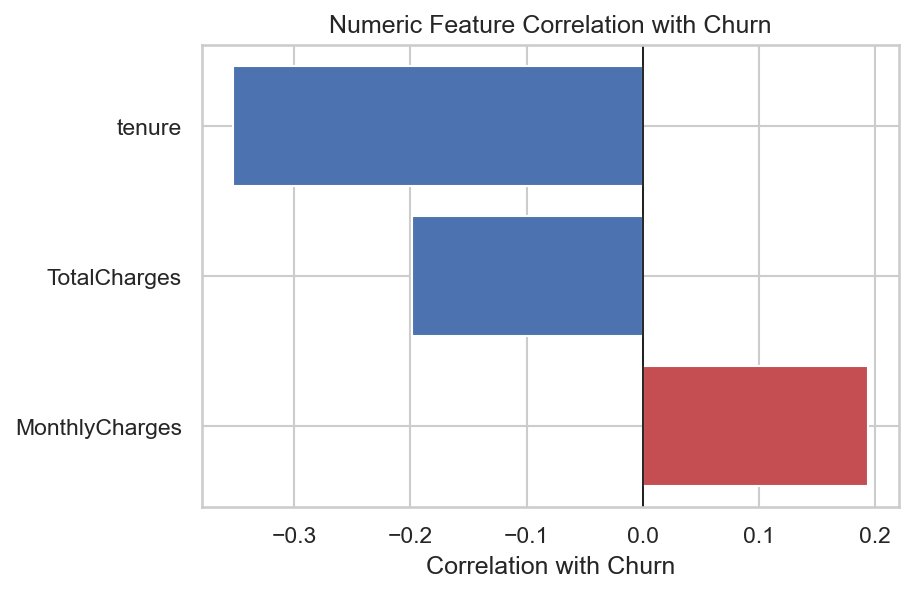

In [4]:
display(Image(str(FIGURES_DIR / "driver_correlation_with_churn.png")))

`tenure` (−0.3522) and `TotalCharges` (−0.1983) both associate with *staying* — longer relationships and higher cumulative spend both signal a customer who has stuck around. `MonthlyCharges` (+0.1934) associates with *leaving*: a higher recurring bill, independent of tenure, pushes toward churn. This is consistent with CLAUDE.md §6's documented tenure signal.

## 2. Chi-square tests on Services columns

Chi-square test of independence + Cramér's V effect size, scoped to CLAUDE.md §6's 9 "Services" columns (`Contract`/`PaymentMethod`/etc. are Account columns, not Services, and are covered separately by SHAP below).

In [5]:
display(chi_square_service_association(df))

,column,chi2,p_value,dof,cramers_v,significant
0,OnlineSecurity,849.9990,2.661150e-185,2,0.3474,True
1,TechSupport,828.1971,1.443084e-180,2,0.3429,True
2,InternetService,732.3096,9.571788e-160,2,0.3225,True
3,OnlineBackup,601.8128,2.079759e-131,2,0.2923,True
4,DeviceProtection,558.4194,5.505219e-122,2,0.2816,True
5,StreamingMovies,375.6615,2.667757e-82,2,0.2310,True
6,StreamingTV,374.2039,5.528994e-82,2,0.2305,True
7,MultipleLines,11.3304,3.464383e-03,2,0.0401,True
8,PhoneService,0.9150,3.387825e-01,1,0.0114,False


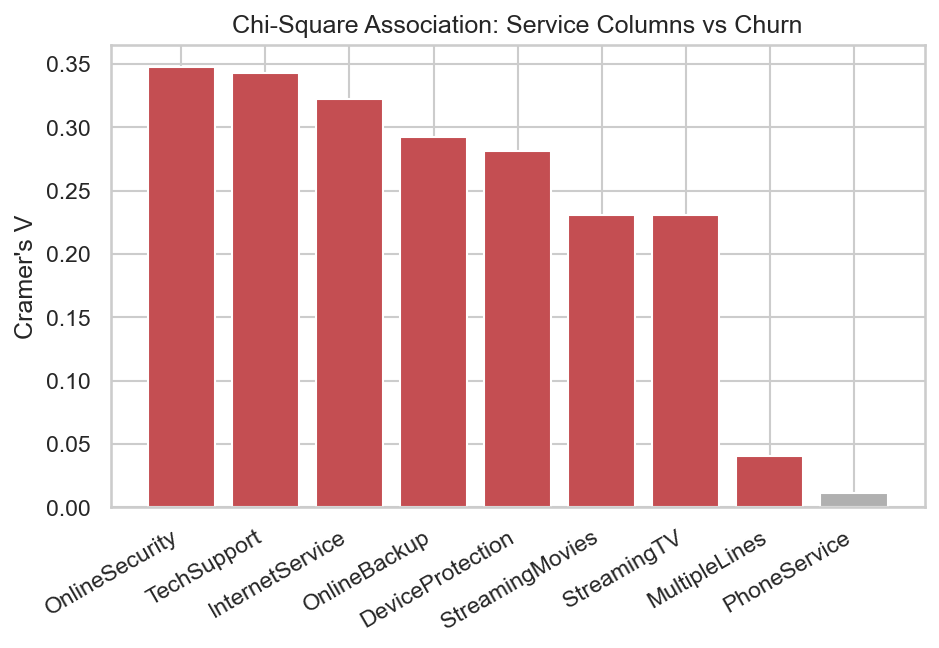

In [6]:
display(Image(str(FIGURES_DIR / "driver_chi_square_service_association.png")))

Every service column is statistically significant at α=0.05 **except `PhoneService`** (p=0.3388, grayed out above) — expected, since roughly 90% of customers have phone service regardless of churn status, so it carries almost no discriminating signal. `OnlineSecurity` (V=0.3474) and `TechSupport` (V=0.3429) are the strongest service-level associations, directly confirming CLAUDE.md §6's tech-support signal with a formal test rather than an eyeballed bar chart.

## 3. Diagnostic model + SHAP global importance

A dedicated XGBoost classifier (`n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42`, `scale_pos_weight` computed from the train split for imbalance) is fit on a stratified 80/20 split purely to produce SHAP values — it is not the Phase 2 production model, is never persisted, and is refit fresh on every call.

In [7]:
result = fit_driver_diagnostic_model(df)
print(f"AUC-ROC: {result['auc']:.4f}")
print(f"PR-AUC:  {result['pr_auc']:.4f}")
print(f"Leakage threshold: {LEAKAGE_AUC_THRESHOLD} (must stay below this)")

AUC-ROC: 0.8360
PR-AUC:  0.6569
Leakage threshold: 0.95 (must stay below this)


AUC-ROC = 0.8360 is *just under* CLAUDE.md §2's ~0.85–0.88 honest band — expected, since this is a single untuned diagnostic model, not Phase 2's eventual compared-and-tuned production one — and far from the >0.95 leakage red flag that would demand investigation. (That band is stated for AUC-ROC specifically; PR-AUC has no equivalent named target, but CLAUDE.md §2 rule 3 requires reporting it alongside AUC on this imbalanced target, which is why both are printed above.) `check_auc_leakage_guard` (called automatically inside `fit_driver_diagnostic_model`) would raise a `ValueError` here if the AUC ever crossed 0.95 — a mechanical enforcement of CLAUDE.md §2 rule 2, not just a comment.

In [8]:
display(shap_global_importance(df, result))

,column,mean_abs_shap
0,Contract,0.8763
1,tenure,0.6096
2,MonthlyCharges,0.3304
3,OnlineSecurity,0.2699
4,TotalCharges,0.2694
5,InternetService,0.2322
6,PaymentMethod,0.2128
7,TechSupport,0.2014
8,MultipleLines,0.1508
9,PaperlessBilling,0.1208


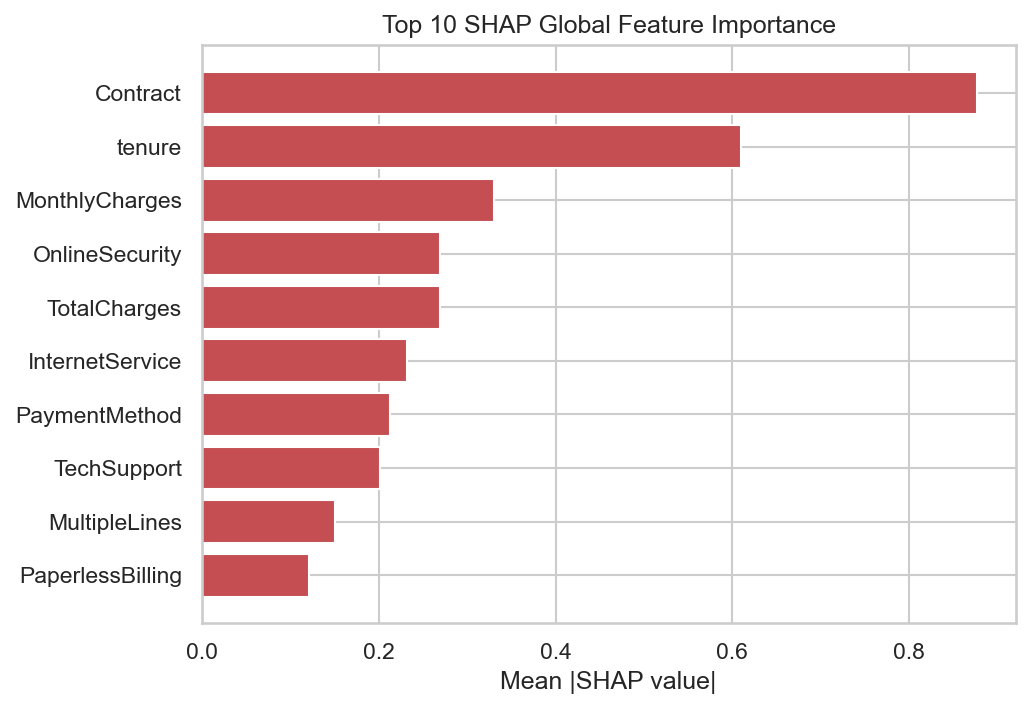

In [9]:
display(Image(str(FIGURES_DIR / "driver_shap_global_importance.png")))

## Cross-method agreement

SHAP is the only one of the three methods that can see `Contract` and `PaymentMethod` at all, since those are Account columns, not Services — and it ranks `Contract` as the single strongest churn driver by a wide margin (0.8763, roughly 1.4x `tenure`'s 0.6096). Checking the top-8 SHAP-ranked columns against CLAUDE.md §6's 5 documented sanity-check signals (`Contract`, `tenure`, `TechSupport`, `PaymentMethod`, `InternetService`): **all 5 land in the top 8** — exactly what CLAUDE.md §6 asks for: *"if these don't show up in SHAP, something is wrong."* This was independently cross-checked during spec research with a 300-tree `RandomForestClassifier` (not shipped, verification only), which surfaced the same top signals in a different order — confirming the finding isn't an XGBoost-specific artifact.

**Aggregation note:** one-hot dummy columns for the same original categorical feature are summed *per row* first (SHAP values are additive, so a row's signed total across a feature's dummies is that feature's actual contribution to that prediction), and only then is the mean absolute value taken across rows — not the other way around. Summing each dummy's own mean(|shap|) independently would overcount features with more levels, since |a| + |b| ≥ |a + b| whenever dummy levels partially offset each other within the same row.

## Key findings

- **Three independent methods agree on the top drivers.** Numeric correlation flags `tenure` and spend; the chi-square test flags `OnlineSecurity` and `TechSupport` among service columns; SHAP — the only method that sees every column — ranks `Contract` as the dominant driver, with `tenure`, `MonthlyCharges`, `OnlineSecurity`, `TotalCharges`, `InternetService`, `PaymentMethod`, and `TechSupport` rounding out the top 8.
- **`PhoneService` is a formally confirmed non-driver** (chi-square p=0.3388) — the honest negative result is itself informative, not hidden.
- **The diagnostic model is honest, not suspicious**: AUC-ROC = 0.8360 (just under CLAUDE.md §2's ~0.85–0.88 honest band, as expected for a single untuned model), PR-AUC = 0.6569, both well under the 0.95 leakage threshold that `check_auc_leakage_guard` enforces automatically.
- **XGBoost was chosen over RandomForest for this diagnostic model specifically because `TreeExplainer` is dramatically faster on it** — about 0.1s vs. several minutes for a comparable 300-tree RandomForest on this dataset — a practical engineering choice, verified during spec research, not just an accuracy one.
- **5 of CLAUDE.md §6's 5 documented sanity-check signals** (`Contract`, `tenure`, `TechSupport`, `PaymentMethod`, `InternetService`) land in the top 8 SHAP-ranked drivers, cross-validating this analysis against real domain knowledge.